# Quantitative Evaluation of Global Political Stability using the World Bank Worldwide Governance Indicators (WGI)

### Abstract
This research notebook analyses the **Political Stability and Absence of Violence/Terrorism (PV)** indicators from the World Bank's Worldwide Governance Indicators (WGI) dataset. It demonstrates data loading, cleaning, filtering, descriptive statistics and visualisation using Python.

### Methodological Notes
* **Data Unit of Analysis:** Long-format country-year observations.
* **Variable Definition:** The `estimate` metric represents the raw country score, normally distributed, ranging roughly between -2.5 (weakest governance performance) and +2.5 (strongest governance performance).
* **Skills Demonstrated:** This notebook demonstrates data import, cleaning, transformation, filtering, descriptive statistical analysis, and comparative data visualisation using Python (pandas, NumPy, Matplotlib, and Seaborn).


### Technical Implementation


1. **Technical Note:** The analysis was conducted in Google Colab. As I was working on a tablet, the dataset was loaded from Google Drive by automatically locating the file instead of manually uploading it.

2. **Data Preparation:** Unlike standard wide-format World Bank extracts that require extensive reshaping via `pd.melt()`, this specific revision was delivered pre-structured in a long (tidy) panel format. The dataset was already in long format, so I didn't need to reshape it before filtering the political indicator

In [ ]:
import os
import pandas as pd
import numpy as np

drive_folder = '/content/drive/MyDrive/'
all_files = os.listdir(drive_folder)
wgi_files = [f for f in all_files if 'wgi' in f.lower()]
first_matched_file = wgi_files[0]
absolute_path = drive_folder + first_matched_file

df = pd.read_excel(absolute_path)
df = df.replace(['..', '...', ' ', ''], np.nan).infer_objects(copy=False)

print("🎯 DYNAMIC SUCCESS: Loaded file: " + first_matched_file)
print(df.columns.tolist()[:5])


🎯 DYNAMIC SUCCESS: Loaded file: wgidataset-2024.xlsx
['codeindyr', 'code', 'countryname', 'year', 'indicator']


/tmp/ipykernel_872/1916376248.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(['..', '...', ' ', ''], np.nan).infer_objects(copy=False)


In [ ]:
# Show the exact column names and the first two rows of data
print("YOUR COLUMNS:")
print(df.columns.tolist())

print("\nDATA PREVIEW:")
print(df.head(2))


YOUR COLUMNS:
['codeindyr', 'code', 'countryname', 'year', 'indicator', 'estimate', 'stddev', 'nsource', 'pctrank', 'pctranklower', 'pctrankupper']

DATA PREVIEW:
   codeindyr code  countryname  year indicator  estimate    stddev  nsource  \
0  AFGcc1996  AFG  Afghanistan  1996        cc -1.291705  0.340507      2.0   
1  ALBcc1996  ALB      Albania  1996        cc -0.893903  0.315914      3.0   

     pctrank  pctranklower  pctrankupper  
0   4.301075      0.000000     27.419355  
1  19.354839      2.688172     43.010754  


**Note:** Countries selected to provide illustrative comparisons across different political and governance contexts. The sample is intended for exploratory visualisation rather than statistical representativeness.

**Target Countries**

* United Kingdom
* United States
* Ukraine
* Colombia
* Singapore
* Nigeria


--- GLOBAL POLITICAL STABILITY DESCRIPTIVE BRIEF (2023) ---
count    2.120000e+02
mean     1.098258e-12
std      1.000000e+00
min     -2.750607e+00
25%     -5.139980e-01
50%      1.221257e-01
75%      7.851796e-01
max      1.744713e+00
Name: estimate, dtype: float64

Top 5 Most Politically Stable Economies (2023):
            countryname  estimate
Jersey, Channel Islands  1.744713
         Cayman Islands  1.625601
          Liechtenstein  1.612758
                Andorra  1.583466
              Greenland  1.495370

Top 5 Least Politically Stable Economies (2023):
         countryname  estimate
Syrian Arab Republic -2.750607
                Mali -2.729136
         Yemen, Rep. -2.562939
         Afghanistan -2.484081
               Sudan -2.466939


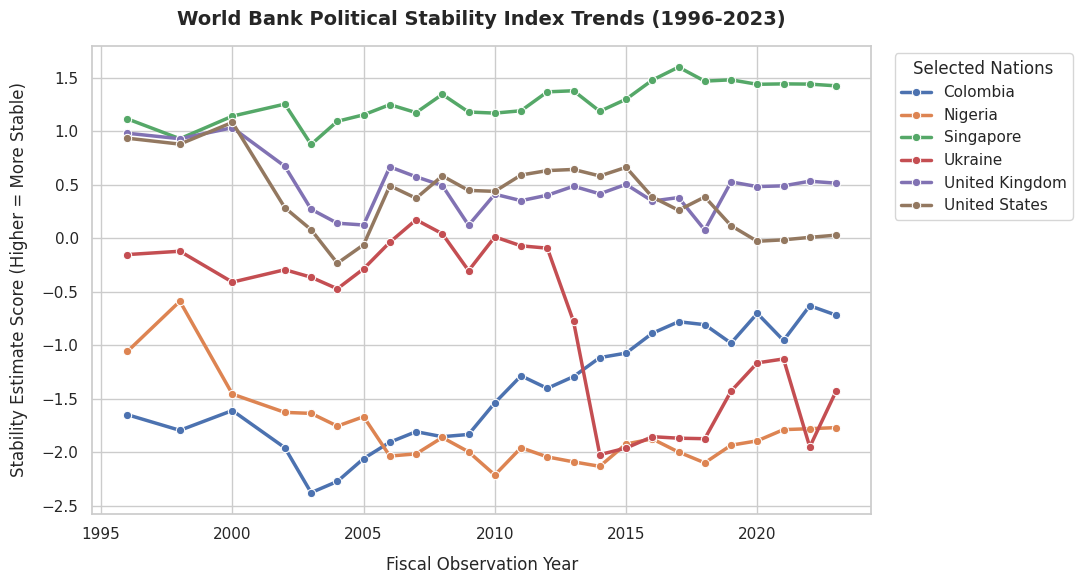

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FILTER FOR POLITICAL STABILITY (PV) ONLY
# The indicator column uses 'pv' as the abbreviation for Political Stability
df_pv = df[df['indicator'].str.lower() == 'pv'].copy()

# Convert the scores to be numeric values for calculation
df_pv['estimate'] = pd.to_numeric(df_pv['estimate'], errors='coerce')
df_pv['year'] = pd.to_numeric(df_pv['year'], errors='coerce')

# Drop any empty records
df_clean = df_pv.dropna(subset=['estimate', 'year']).copy()

# 2. # Produce descriptive summary of political stability estimates
latest_year = int(df_clean['year'].max())
df_latest = df_clean[df_clean['year'] == latest_year]

print(f"--- GLOBAL POLITICAL STABILITY DESCRIPTIVE BRIEF ({latest_year}) ---")
print(df_latest['estimate'].describe())

print(f"\nTop 5 Most Politically Stable Economies ({latest_year}):")
print(df_latest.sort_values(by='estimate', ascending=False)[['countryname', 'estimate']].head(5).to_string(index=False))

print(f"\nTop 5 Least Politically Stable Economies ({latest_year}):")
print(df_latest.sort_values(by='estimate', ascending=True)[['countryname', 'estimate']].head(5).to_string(index=False))

# 3. GENERATE THE POLICY COMPARISON VISUALISATION
# Select a balanced cross-section of countries for comparative research
target_countries = ['United Kingdom', 'United States', 'Ukraine', 'Colombia', 'Singapore', 'Nigeria']
df_plot = df_clean[df_clean['countryname'].isin(target_countries)]

# Set up clean visual styling for a research paper layout
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# Create the trajectory timeline
sns.lineplot(data=df_plot, x='year', y='estimate', hue='countryname', marker='o', linewidth=2.5)

# Add academic titles and clear context labels
plt.title(f'World Bank Political Stability Index Trends ({int(df_clean["year"].min())}-{latest_year})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fiscal Observation Year', fontsize=12, labelpad=10)
plt.ylabel('Stability Estimate Score (Higher = More Stable)', fontsize=12, labelpad=10)

# Position legend cleanly outside the visual box
plt.legend(title='Selected Nations', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

# Save a high-resolution export image for portfolios
plt.savefig('political_stability_trends_2024.png', dpi=300)
plt.show()


###Findings
The descriptive analysis indicates considerable cross-national variation in political stability. Small European jurisdictions and overseas territories occupy the highest positions in the 2023 estimates, whereas countries experiencing prolonged conflict or state fragility occupy the lowest positions. The comparative time-series illustrates differing trajectories of political stability across selected countries and demonstrates the usefulness of longitudinal governance indicators for exploratory political analysis.

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!pip install geodatasets

In [ ]:
import geopandas as gpd
from geodatasets import get_path

world = gpd.read_file(get_path("naturalearth.land"))

world.head()

,featurecla,scalerank,min_zoom,geometry
0,Land,1,1.0,"POLYGON ((-59.57209 -80.04018, -59.86585 -80.5..."
1,Land,1,1.0,"POLYGON ((-159.20818 -79.49706, -161.1276 -79...."
2,Land,1,0.0,"POLYGON ((-45.15476 -78.04707, -43.92083 -78.4..."
3,Land,1,1.0,"POLYGON ((-121.21151 -73.50099, -119.91885 -73..."
4,Land,1,1.0,"POLYGON ((-125.55957 -73.48135, -124.03188 -73..."


In [ ]:
import geodatasets

geodatasets.data

{'geoda': {'airbnb': {'url': 'https://geodacenter.github.io/data-and-lab//data/airbnb.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.airbnb',
   'description': 'Airbnb rentals, socioeconomics, and crime in Chicago',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//airbnb/',
   'hash': 'a2ab1e3f938226d287dd76cde18c00e2d3a260640dd826da7131827d9e76c824',
   'filename': 'airbnb.zip'},
  'atlanta': {'url': 'https://geodacenter.github.io/data-and-lab//data/atlanta_hom.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.atlanta',
   'description': 'Atlanta, GA region homicide counts and rates',
   'geometry_type': 'Polygon',
   'nrows': 90,
   'ncols': 24,
   'details': 'https://geodacenter.github.io/data-and-lab//atlanta_old/',
   'hash': 'a33a76e12168fe84361e60c88a9df4856730487305846c559715c89b1a2b5e09',
   'filename': 'atlanta_hom.zip',
   'members': ['atlanta_hom/atl_hom.geojson']},
  'cars': {'url': 'https://geodacenter.github.io/data-and-lab//data/Abandoned_Vehicles_Map.csv',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.cars',
   'description': '2011 abandoned vehicles in Chicago (311 complaints).',
   'geometry_type': 'Point',
   'nrows': 137867,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//1-source-and-description/',
   'hash': '6a0b23bc7eda2dcf1af02d43ccf506b24ca8d8c6dc2fe86a2a1cc051b03aae9e',
   'filename': 'Abandoned_Vehicles_Map.csv'},
  'charleston1': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston1',
   'description': '2000 Census Tract Data for Charleston, SC MSA and counties',
   'geometry_type': 'Polygon',
   'nrows': 117,
   'ncols': 31,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston-1_old/',
   'hash': '4a4fa9c8dd4231ae0b2f12f24895b8336bcab0c28c48653a967cffe011f63a7c',
   'filename': 'CharlestonMSA.zip',
   'members': ['CharlestonMSA/sc_final_census2.gpkg']},
  'charleston2': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA2.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston2',
   'description': '1998 and 2001 Zip Code Business Patterns (Census Bureau) for Charleston, SC MSA',
   'geometry_type': 'Polygon',
   'nrows': 42,
   'ncols': 60,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston2/',
   'hash': '056d5d6e236b5bd95f5aee26c77bbe7d61bd07db5aaf72866c2f545205c1d8d7',
   'filename': 'CharlestonMSA2.zip',
   'members': ['CharlestonMSA2/CharlestonMSA2.gpkg']},
  'chicago_health': {'url': 'https://geodacenter.github.io/data-and-lab//data/comarea.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_health',
   'description': 'Chicago Health + Socio-Economics',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 87,
   'details': 'https://geodacenter.github.io/data-and-lab//comarea_vars/',
   'hash': '4e872adb552786eae2fcd745524696e5e4cd33cc9a6c032471c0e75328871401',
   'filename': 'comarea.zip'},
  'chicago_commpop': {'url': 'https://geodacenter.github.io/data-and-lab//data/chicago_commpop.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_commpop',
   'description': 'Chicago Community Area Population Percent Change for 2000 and 2010',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 9,
   'details': 'https://geodacenter.github.io/data-and-lab//commpop/',
   'hash': '1dbebb50c8ea47e2279ea819ef64ba793bdee2b88e4716bd6c6ec0e0d8e0e05b',
   'filename': 'c

In [ ]:
geodatasets.data.naturalearth

{'cities': {'url': 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip',
  'license': 'CC0',
  'attribution': 'Natural Earth',
  'name': 'naturalearth.cities',
  'description': 'Point symbols with name attributes of all admin-0 capitals and some other major cities.',
  'geometry_type': 'Point',
  'details': 'https://www.naturalearthdata.com/downloads/110m-cultural-vectors/110m-populated-places/',
  'nrows': 243,
  'ncols': 32,
  'hash': '3f3d99a9a5d84605bb3be07b94c9122b4d69d7545de478b314d75f5b0742afdf',
  'filename': 'ne_110m_populated_places_simple.zip'},
 'lakes': {'url': 'https://naciscdn.org/naturalearth/110m/physical/ne_110m_lakes.zip',
  'license': 'CC0',
  'attribution': 'Natural Earth',
  'name': 'naturalearth.lakes',
  'description': 'Major natural and artificial lakes polygons.',
  'geometry_type': 'Polygon',
  'details': 'https://www.naturalearthdata.com/downloads/10m-physical-vectors/10m-lakes/',
  'nrows': 24,
  'ncols': 38,
  'hash': 'f2eed3c738a93010770acb0ba44273ea6a83b053641588bc902d9d6fd1cdafcb',
  'filename': 'ne_110m_lakes.zip'},
 'land': {'url': 'https://naciscdn.org/naturalearth/110m/physical/ne_110m_land.zip',
  'license': 'CC0',
  'attribution': 'Natural Earth',
  'name': 'naturalearth.land',
  'description': 'Land polygons including major islands in a 1:110m resolution.',
  'geometry_type': 'Polygon',
  'details': 'https://www.naturalearthdata.com/downloads/110m-physical-vectors/110m-land/',
  'nrows': 127,
  'ncols': 4,
  'hash': '1926c621afd6ac67c3f36639bb1236134a48d82226dc675d3e3df53d02d2a3de',
  'filename': 'ne_110m_land.zip'}}

In [ ]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"

world = gpd.read_file(url)

world.head()

,name,ISO3166-1-Alpha-3,ISO3166-1-Alpha-2,geometry
0,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4..."
1,Malaysia,MYS,MY,"MULTIPOLYGON (((117.70361 4.16342, 117.69711 4..."
2,Chile,CHL,CL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Bolivia,BOL,BO,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Peru,PER,PE,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


In [ ]:
df.head()

,codeindyr,code,countryname,year,indicator,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper
0,AFGcc1996,AFG,Afghanistan,1996,cc,-1.291705,0.340507,2.0,4.301075,0.000000,27.419355
1,ALBcc1996,ALB,Albania,1996,cc,-0.893903,0.315914,3.0,19.354839,2.688172,43.010754
2,DZAcc1996,DZA,Algeria,1996,cc,-0.566741,0.262077,4.0,33.333332,16.666666,52.688171
3,ASMcc1996,ASM,American Samoa,1996,cc,NaN,NaN,NaN,NaN,NaN,NaN
4,ADOcc1996,ADO,Andorra,1996,cc,1.318143,0.480889,1.0,87.096771,72.043015,96.774193


In [ ]:
df.head()

,codeindyr,code,countryname,year,indicator,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper
0,AFGcc1996,AFG,Afghanistan,1996,cc,-1.291705,0.340507,2.0,4.301075,0.000000,27.419355
1,ALBcc1996,ALB,Albania,1996,cc,-0.893903,0.315914,3.0,19.354839,2.688172,43.010754
2,DZAcc1996,DZA,Algeria,1996,cc,-0.566741,0.262077,4.0,33.333332,16.666666,52.688171
3,ASMcc1996,ASM,American Samoa,1996,cc,NaN,NaN,NaN,NaN,NaN,NaN
4,ADOcc1996,ADO,Andorra,1996,cc,1.318143,0.480889,1.0,87.096771,72.043015,96.774193


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df.columns

Index(['codeindyr', 'code', 'countryname', 'year', 'indicator', 'estimate',
       'stddev', 'nsource', 'pctrank', 'pctranklower', 'pctrankupper'],
      dtype='object')

In [ ]:
df["estimate"] = pd.to_numeric(df["estimate"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

In [ ]:
pv_data = df[df["indicator"].str.lower() == "pv"]

In [ ]:
pv_data.head()

,codeindyr,code,countryname,year,indicator,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper
428,AFGpv1996,AFG,Afghanistan,1996,pv,-2.417310,0.474807,2.0,2.127660,0.000000,6.914894
429,ALBpv1996,ALB,Albania,1996,pv,-0.336625,0.421716,3.0,35.638298,17.021276,57.446808
430,DZApv1996,DZA,Algeria,1996,pv,-1.783311,0.373912,4.0,5.319149,2.127660,12.234042
431,ASMpv1996,ASM,American Samoa,1996,pv,NaN,NaN,NaN,NaN,NaN,NaN
432,ADOpv1996,ADO,Andorra,1996,pv,1.169522,0.613031,1.0,89.361702,52.127659,100.000000


In [ ]:
pv_data.shape

(5350, 11)

In [ ]:
pv_clean = pv_data.dropna(subset=["estimate", "year"])

In [ ]:
pv_clean.shape

(5178, 11)

In [ ]:
latest_year = pv_clean["year"].max()

pv_latest = pv_clean[pv_clean["year"] == latest_year]

pv_latest.head()

,codeindyr,code,countryname,year,indicator,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper
31244,AFGpv2023,AFG,Afghanistan,2023,pv,-2.484081,0.234416,5.0,1.421801,0.000000,4.739336
31245,ALBpv2023,ALB,Albania,2023,pv,0.183349,0.227245,6.0,51.658768,40.284359,63.507111
31246,DZApv2023,DZA,Algeria,2023,pv,-0.577885,0.227245,6.0,23.222750,14.218010,39.810425
31247,ASMpv2023,ASM,American Samoa,2023,pv,1.114221,0.398109,1.0,91.943130,60.663506,100.000000
31248,ADOpv2023,ADO,Andorra,2023,pv,1.583466,0.278450,3.0,98.578201,91.943130,100.000000


In [ ]:
pv_clean[pv_clean["year"] == latest_year]

,codeindyr,code,countryname,year,indicator,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper
31244,AFGpv2023,AFG,Afghanistan,2023,pv,-2.484081,0.234416,5.0,1.421801,0.000000,4.739336
31245,ALBpv2023,ALB,Albania,2023,pv,0.183349,0.227245,6.0,51.658768,40.284359,63.507111
31246,DZApv2023,DZA,Algeria,2023,pv,-0.577885,0.227245,6.0,23.222750,14.218010,39.810425
31247,ASMpv2023,ASM,American Samoa,2023,pv,1.114221,0.398109,1.0,91.943130,60.663506,100.000000
31248,ADOpv2023,ADO,Andorra,2023,pv,1.583466,0.278450,3.0,98.578201,91.943130,100.000000
...,...,...,...,...,...,...,...,...,...,...,...
31453,VIRpv2023,VIR,Virgin Islands (U.S.),2023,pv,0.534723,0.307409,2.0,63.033176,47.393364,87.203789
31454,WBGpv2023,WBG,West Bank and Gaza,2023,pv,-1.865219,0.238989,5.0,7.109005,2.843602,9.478673
31455,YEMpv2023,YEM,"Yemen, Rep.",2023,pv,-2.562939,0.235312,5.0,0.947867,0.000000,3.791469
31456,ZMBpv2023,ZMB,Zambia,2023,pv,0.201727,0.227245,6.0,52.132702,40.284359,64.454979


In [ ]:
latest_year

2023

In [ ]:
pv_latest.shape

(212, 11)

In [ ]:
world.head()

,name,ISO3166-1-Alpha-3,ISO3166-1-Alpha-2,geometry
0,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4..."
1,Malaysia,MYS,MY,"MULTIPOLYGON (((117.70361 4.16342, 117.69711 4..."
2,Chile,CHL,CL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Bolivia,BOL,BO,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Peru,PER,PE,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


In [ ]:
pv_latest[["countryname", "code", "estimate"]].head()

,countryname,code,estimate
31244,Afghanistan,AFG,-2.484081
31245,Albania,ALB,0.183349
31246,Algeria,DZA,-0.577885
31247,American Samoa,ASM,1.114221
31248,Andorra,ADO,1.583466


In [ ]:
world_pv = world.merge(
      pv_latest,
          left_on="ISO3166-1-Alpha-3",
              right_on="code",
                  how="left"
                  )


In [ ]:
world_pv[["name", "estimate"]].head()

,name,estimate
0,Indonesia,-0.404375
1,Malaysia,0.168515
2,Chile,0.136160
3,Bolivia,-0.313184
4,Peru,-0.521786


In [ ]:
import matplotlib.pyplot as plt

<Axes: >

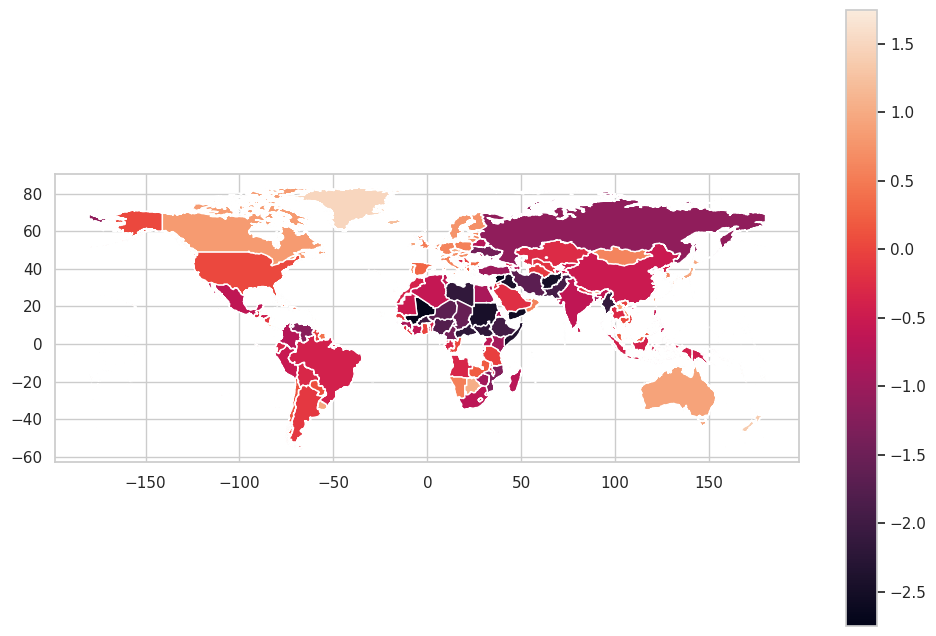

In [ ]:
world_pv.plot(
      column="estimate",
          figsize=(12, 8),
              legend=True
              )

Text(0.5, 1.0, 'Political Stability and Absence of Violence/Terrorism (2023)')

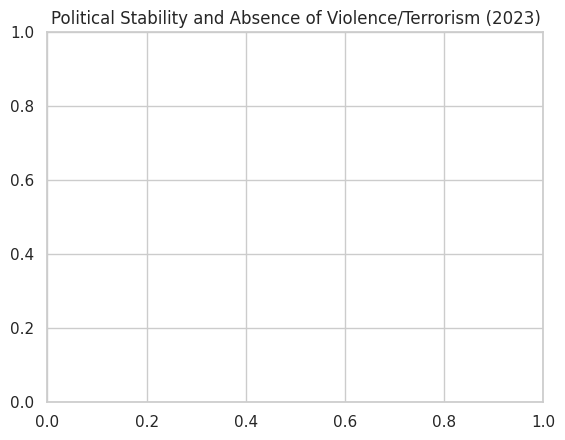

In [ ]:
plt.title("Political Stability and Absence of Violence/Terrorism (2023)")

In [ ]:
world_pv.geometry.head()

,geometry
0,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4..."
1,"MULTIPOLYGON (((117.70361 4.16342, 117.69711 4..."
2,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


In [ ]:
world_pv["estimate"].isna().sum()

np.int64(57)

In [ ]:
world_pv.shape

(258, 15)

In [ ]:
world_pv["estimate"].isna().sum()

np.int64(57)

In [ ]:
import matplotlib.pyplot as plt

<Axes: >

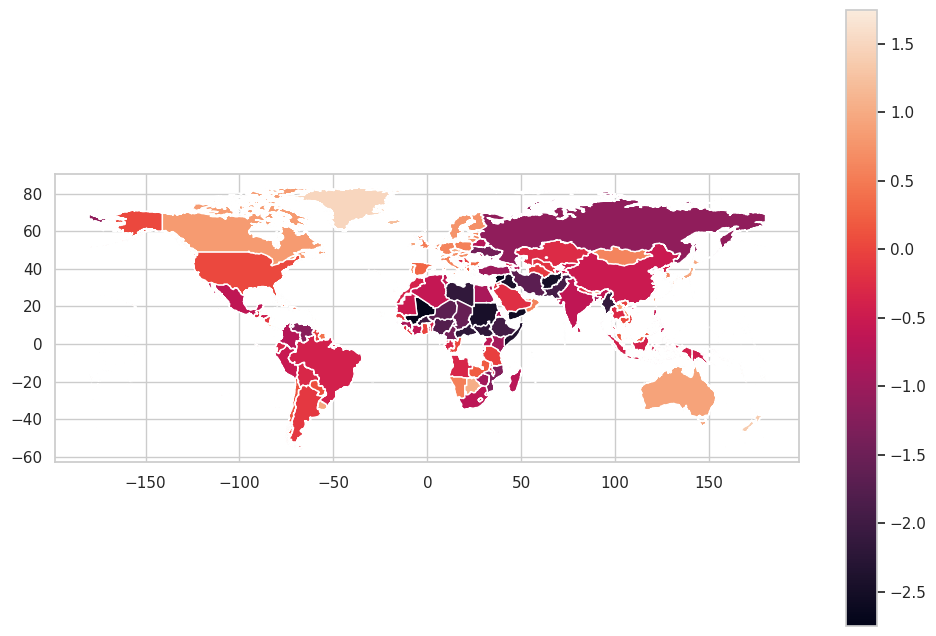

In [ ]:
world_pv.plot(column="estimate", figsize=(12,8), legend=True)

In [ ]:
plt.show()

Text(0.5, 1.0, 'Political Stability and Absence of Violence/Terrorism (2023)')

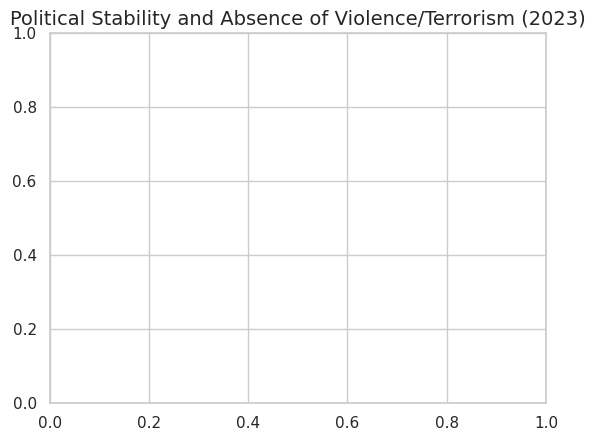

In [ ]:
plt.title(
      "Political Stability and Absence of Violence/Terrorism (2023)",
          fontsize=14
          )

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

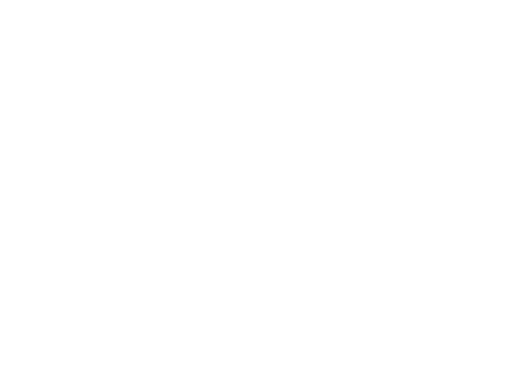

In [ ]:
plt.axis("off")

In [ ]:
plt.savefig(
      "political_stability_2023_map.png",
          dpi=300,
              bbox_inches="tight"
              )

<Figure size 640x480 with 0 Axes>

In [ ]:
world_pv.to_file(
      "political_stability_2023.gpkg",
          layer="wgi_political_stability",
              driver="GPKG"
              )

In [ ]:
import os

os.listdir()

['.config',
 'political_stability_trends_2024.png',
 'political_stability_2023.gpkg',
 'political_stability_2023_map.png',
 'drive',
 'sample_data']

In [ ]:
import shutil

In [ ]:
shutil.copy("political_stability_2023_map.png", "/content/drive/MyDrive/political_stability_2023_map.png")

'/content/drive/MyDrive/political_stability_2023_map.png'

In [ ]:
shutil.copy("political_stability_2023.gpkg", "/content/drive/MyDrive/political_stability_2023.gpkg")

'/content/drive/MyDrive/political_stability_2023.gpkg'

In [ ]:
import os

os.path.exists("/content/drive/MyDrive/political_stability_2023_map.png")

True

## Methodology

This project uses the World Bank Worldwide Governance Indicators (WGI) dataset, focusing on the Political Stability and Absence of Violence/Terrorism (PV) indicator. The analysis was conducted in Python using pandas for data preparation and GeoPandas for spatial analysis.

The dataset was cleaned by converting numerical fields, removing missing observations, and filtering the political stability indicator. The latest available year (2023) was selected for spatial comparison. Country-level governance scores were then joined with Natural Earth geographic boundaries using ISO-3 country codes to produce a global choropleth map.

## Key Findings

The 2023 political stability indicator shows substantial variation across countries. Higher stability scores are concentrated among countries with stronger governance conditions, while lower scores are associated with countries experiencing conflict, political instability, or institutional challenges.

The lowest-scoring cases included Syria, Mali, Yemen, Afghanistan, and Sudan, while higher-scoring cases included several smaller European territories and island economies.